In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import norm
import scipy
import os
import re

Todo
* Yield curve with different types of assets (Sofr, Bonds, etc.)
* Same analysis but with more historical data: implied volatility VS actual volatility
* Interpolation in 1D
* More advanced interpolation 2D moneyness & term VS ...
* use unsupervized ML algorithms to remove extreme points

## Data preparation

In [54]:
# Average of the last 30 days of annualized sofr rates
risk_free_rate = 3.64516 / 100.0

# Today
today = pd.Timestamp(year=2026, month=4, day=23, tz="UTC")

# As of the time the data was downloaded
price = 372.825 # 373.72

### Option Data

In [55]:
ticker_str = "TSLA"
available_data = filter(lambda x: ticker_str in x, os.listdir("data"))
dataframes = {}
for filename in available_data:
    dates = re.search("(\d{4})-(\d{2})-(\d{2})", filename)
    if not dates:
        continue
    year, month, day = tuple(int(el) for el in dates.groups())
    contract_type = "call" if "calls" in filename else "put"
    dataframes[pd.Timestamp(year=year, month=month, day=day, tz="UTC")] = (contract_type, pd.read_csv(f"./data/{filename}"))

In [56]:
cols = ["strike", "bid", "ask", "last_price", "yahoo_implied_vol", "type", "last_trade_date", "maturity"]
data = pd.DataFrame(columns=cols)

for maturity, (option_type, df) in dataframes.items():
    extract = df[["strike", "bid", "ask", "impliedVolatility", "lastTradeDate", "lastPrice"]].copy()
    extract["type"] = option_type
    extract["maturity"] = maturity
    extract = extract.rename({"lastPrice": "last_price", "lastTradeDate": "last_trade_date", "impliedVolatility": "yahoo_implied_vol"}, axis="columns")
    extract["last_trade_date"] = pd.to_datetime(extract["last_trade_date"])
    data = pd.concat([data, extract[cols]], axis=0, ignore_index=True)

data = data[ data["last_trade_date"] >= today - pd.DateOffset(days=1)]
data["time_to_maturity"] = (data["maturity"] - today).dt.days / 360
data["moneyness"] = data["strike"] / price
data["price"] = 0.5*(data["bid"]+data["ask"])

data_put = data[data["type"] == "put"].copy()
data_call = data[data["type"] == "call"].copy()

/tmp/ipykernel_7627/1949616465.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat([data, extract[cols]], axis=0, ignore_index=True)


In [57]:
data.head()

,strike,bid,ask,last_price,yahoo_implied_vol,type,last_trade_date,maturity,time_to_maturity,moneyness,price
0,5.0,366.40,372.85,370.29,1.805665,call,2026-04-23 18:12:12+00:00,2028-01-21 00:00:00+00:00,1.772222,0.013411,369.625
14,100.0,282.10,287.00,280.50,0.830202,call,2026-04-23 14:27:22+00:00,2028-01-21 00:00:00+00:00,1.772222,0.268222,284.550
19,150.0,241.75,244.10,245.00,0.722659,call,2026-04-23 17:02:36+00:00,2028-01-21 00:00:00+00:00,1.772222,0.402334,242.925
24,190.0,210.30,212.85,213.28,0.661228,call,2026-04-23 18:40:30+00:00,2028-01-21 00:00:00+00:00,1.772222,0.509622,211.575
26,200.0,203.15,206.25,211.50,0.654606,call,2026-04-23 15:56:48+00:00,2028-01-21 00:00:00+00:00,1.772222,0.536445,204.700


### Yield Curve

## Yield curve

## Implied volatility surface

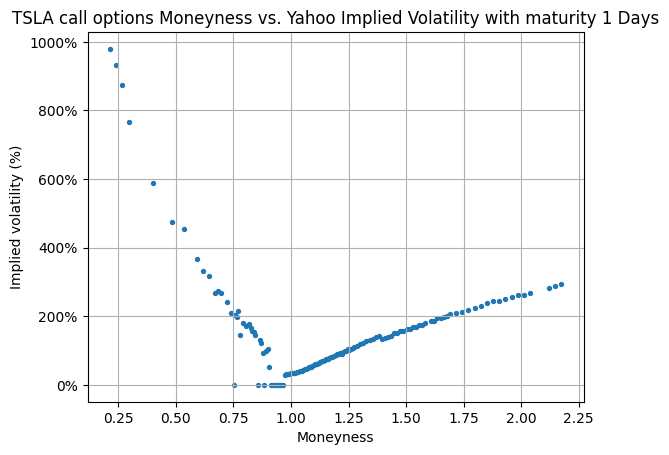

In [58]:
maturity_plot = data_call["time_to_maturity"].value_counts().idxmax()
days = int(maturity_plot*360)
call_plot = data_call[data_call["time_to_maturity"] == maturity_plot]

plt.scatter(call_plot["moneyness"], call_plot["yahoo_implied_vol"], s=8)
plt.ylabel("Implied volatility (%)")
plt.xlabel("Moneyness")
plt.title(f"TSLA call options Moneyness vs. Yahoo Implied Volatility with maturity {days} Days")

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))

plt.grid(True)
plt.show()

### Naïve aproaches

In [59]:
def call_price(risk_free_rate, maturity, K, S, volatility):
    d1 = (np.log(S / K) + (risk_free_rate + 0.5*volatility**2)*maturity) / (volatility*np.sqrt(maturity))
    d2 = d1 - volatility*np.sqrt(maturity)
    return S*norm.cdf(d1) - K*np.exp(-risk_free_rate*maturity)*norm.cdf(d2)

def put_price(risk_free_rate, maturity, K, S, volatility):
    return call_price(risk_free_rate, maturity, K, S, volatility) - S + K*np.exp(-risk_free_rate*maturity)

In [60]:
def implied_volatility_dichotomy(time_to_maturity, risk_free_rate, strike, price, option_price, tol=0.01, max_iter = 50):
    upper = 1000.0 / 100.0
    lower = 10.0 / 100.0

    for _ in range(max_iter):
        price_upper = call_price(risk_free_rate, time_to_maturity, strike, price, upper)
        price_lower = call_price(risk_free_rate, time_to_maturity, strike, price, lower)

        # print("="*20)
        # print(lower, price_lower)
        # print(option_price)
        # print(upper, price_upper)

        if option_price >= price_upper:
            lower = upper
            upper = 2*upper
        elif option_price <= price_lower:
            upper = lower
            lower = 0.5*lower
        else:
            middle = 0.5*(upper+lower)
            price_middle = call_price(risk_free_rate, time_to_maturity, strike, price, lower)
            if price_middle >= option_price:
                upper = middle
            else:
                lower = middle

        if abs(option_price - 0.5*(price_upper+price_lower)) < tol:
            return (upper+lower)/2

    return (upper+lower)/2

In [101]:
def implied_volatility(time_to_maturity, risk_free_rate, strike, price, option_price, tol=0.01):
    def target(x):
        diff = call_price(risk_free_rate, time_to_maturity, strike, price, np.exp(x)) - option_price
        return diff**2
    res = scipy.optimize.minimize(target, x0=np.exp(100/100.0), tol=tol, method="Nelder-Mead")
    return np.exp(res.x)

In [102]:
data_call["implied_vol"] = 0.0
for (k, option) in data_call.iterrows():
    impl_vol = implied_volatility(option["time_to_maturity"], risk_free_rate, option["strike"], price, option["price"], tol=0.01)
    data_call.loc[k, "implied_vol"] = impl_vol

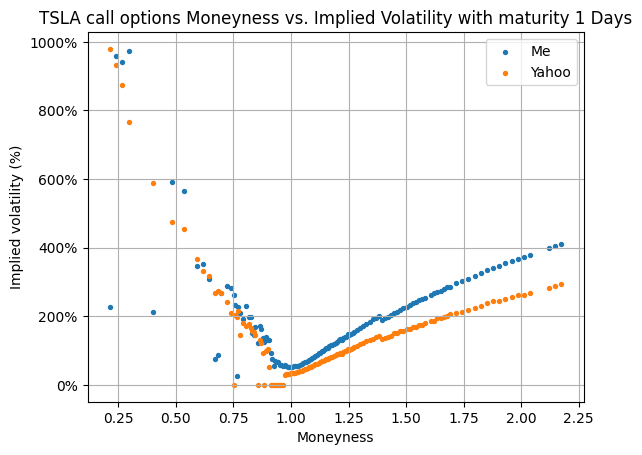

In [103]:
maturity_plot = data_call["time_to_maturity"].value_counts().idxmax()
days = int(maturity_plot*360)
call_plot = data_call[data_call["time_to_maturity"] == maturity_plot]

plt.scatter(call_plot["moneyness"], call_plot["implied_vol"], s=8, label="Me")
plt.scatter(call_plot["moneyness"], call_plot["yahoo_implied_vol"], s=8, label="Yahoo")
plt.ylabel("Implied volatility (%)")
plt.xlabel("Moneyness")
plt.title(f"TSLA call options Moneyness vs. Implied Volatility with maturity {days} Days")

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))

plt.legend()
plt.grid(True)
plt.show()